# RLHF/ALIGNMENT(对齐)
## pre_training->post training
模型遵循符合指令/安全审查，防护措施
 - **今天的目标：对于一个语言模型生成的文本加强可控性**

# POST TRAINING
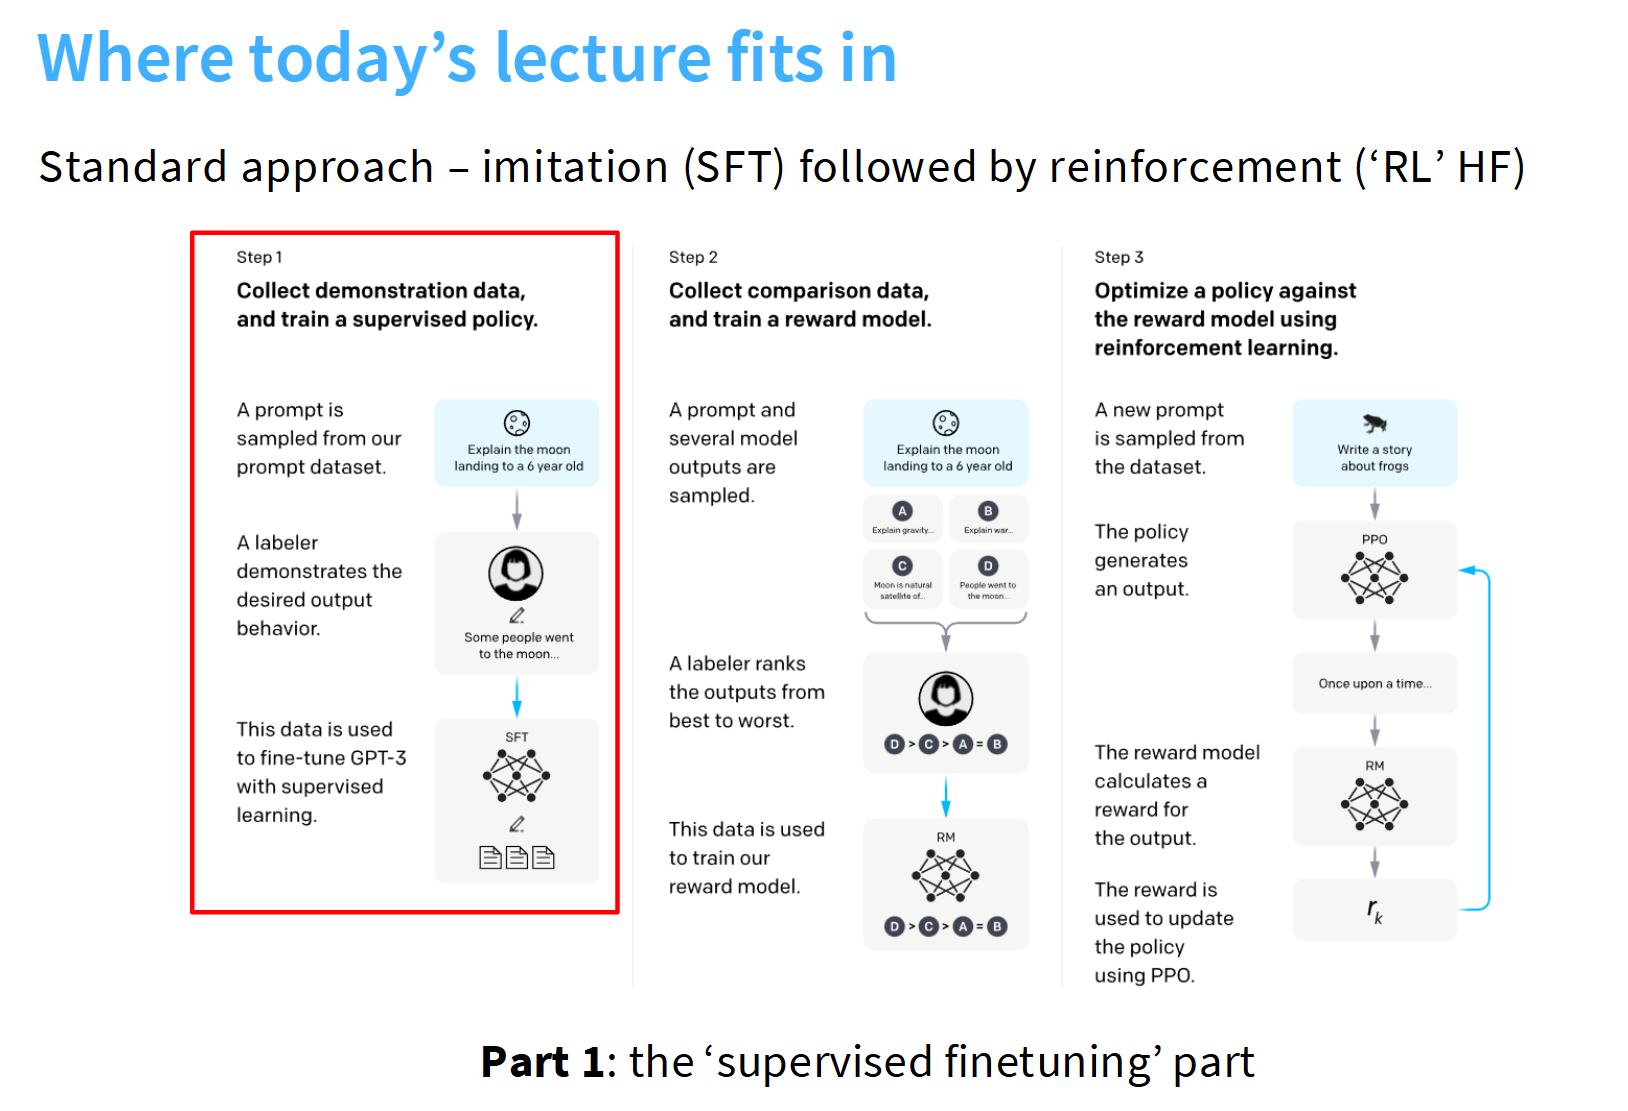
根据论文的思路进行推演        
## supervised fine tuning
### 两个要素
#### training data
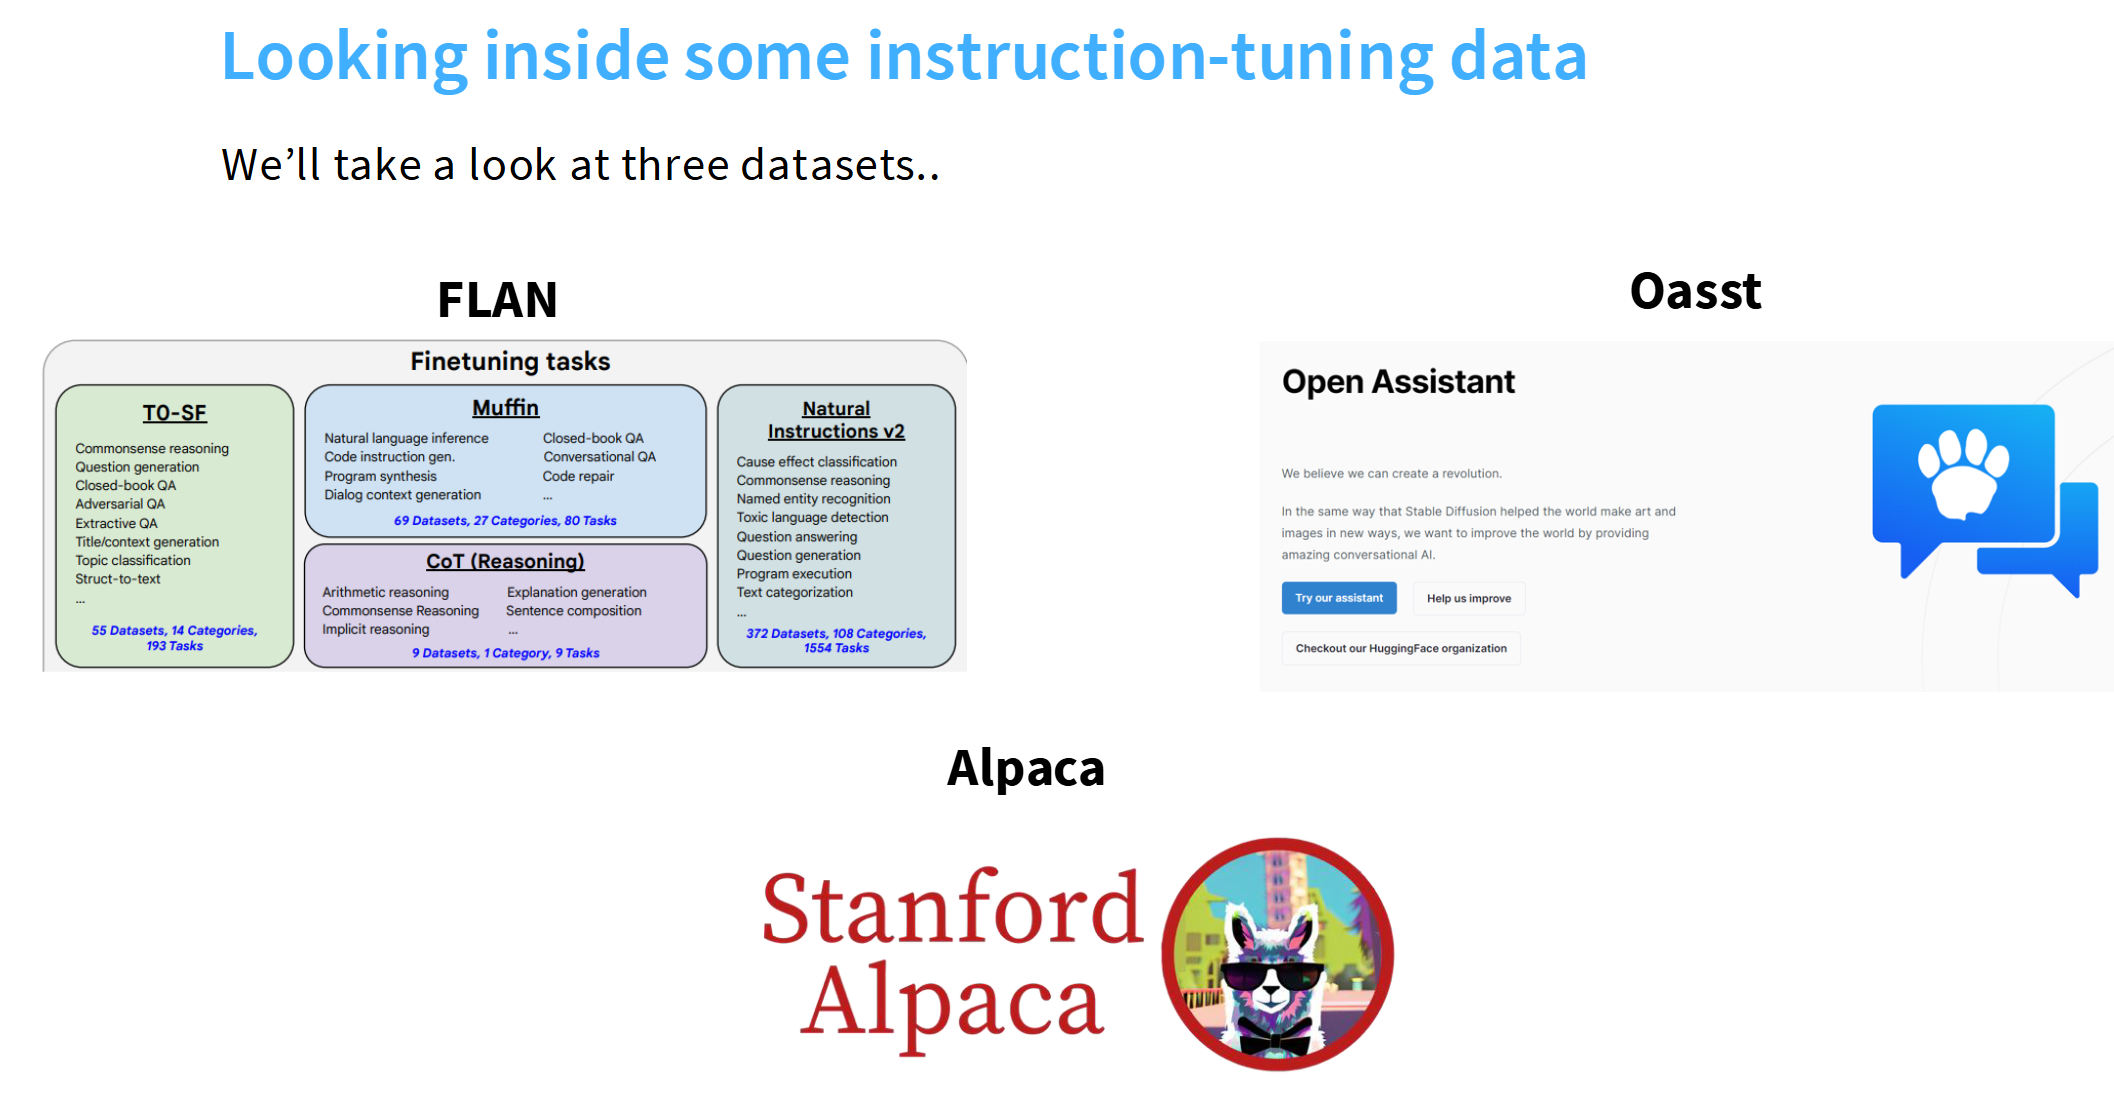
 - FAN:通过大量来自自然语言处理的训练数据来构建的
     - 可以看到各个任务的数据集（缩写文档，摘要，多项选择，数据库）
     - 因为把所有的数据收集起来，所以可以获得海量数据，但是也会有问题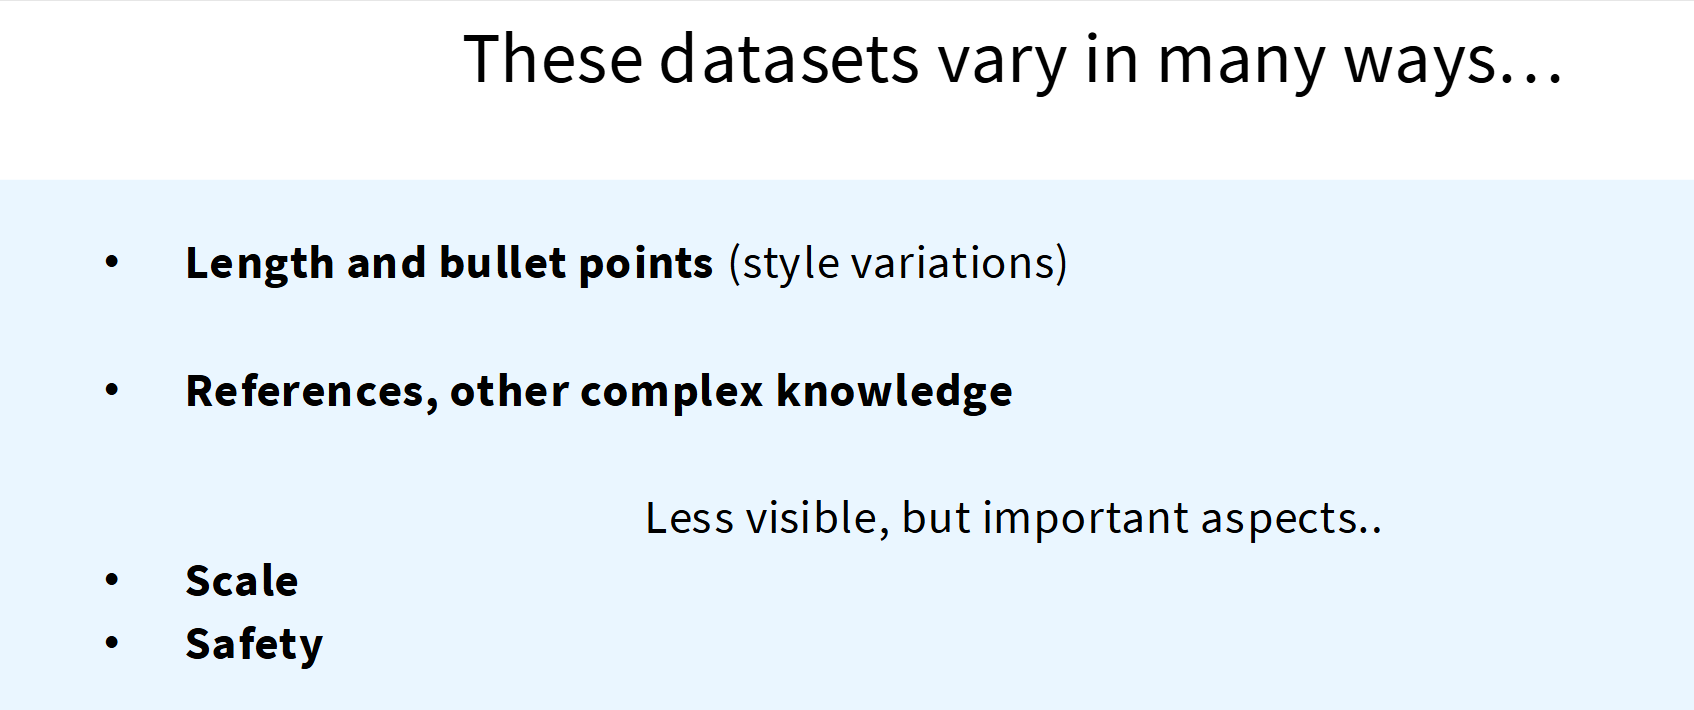
     - 一个比较新的尝试：<mark>用语言模型来生成指令微调数据</mark>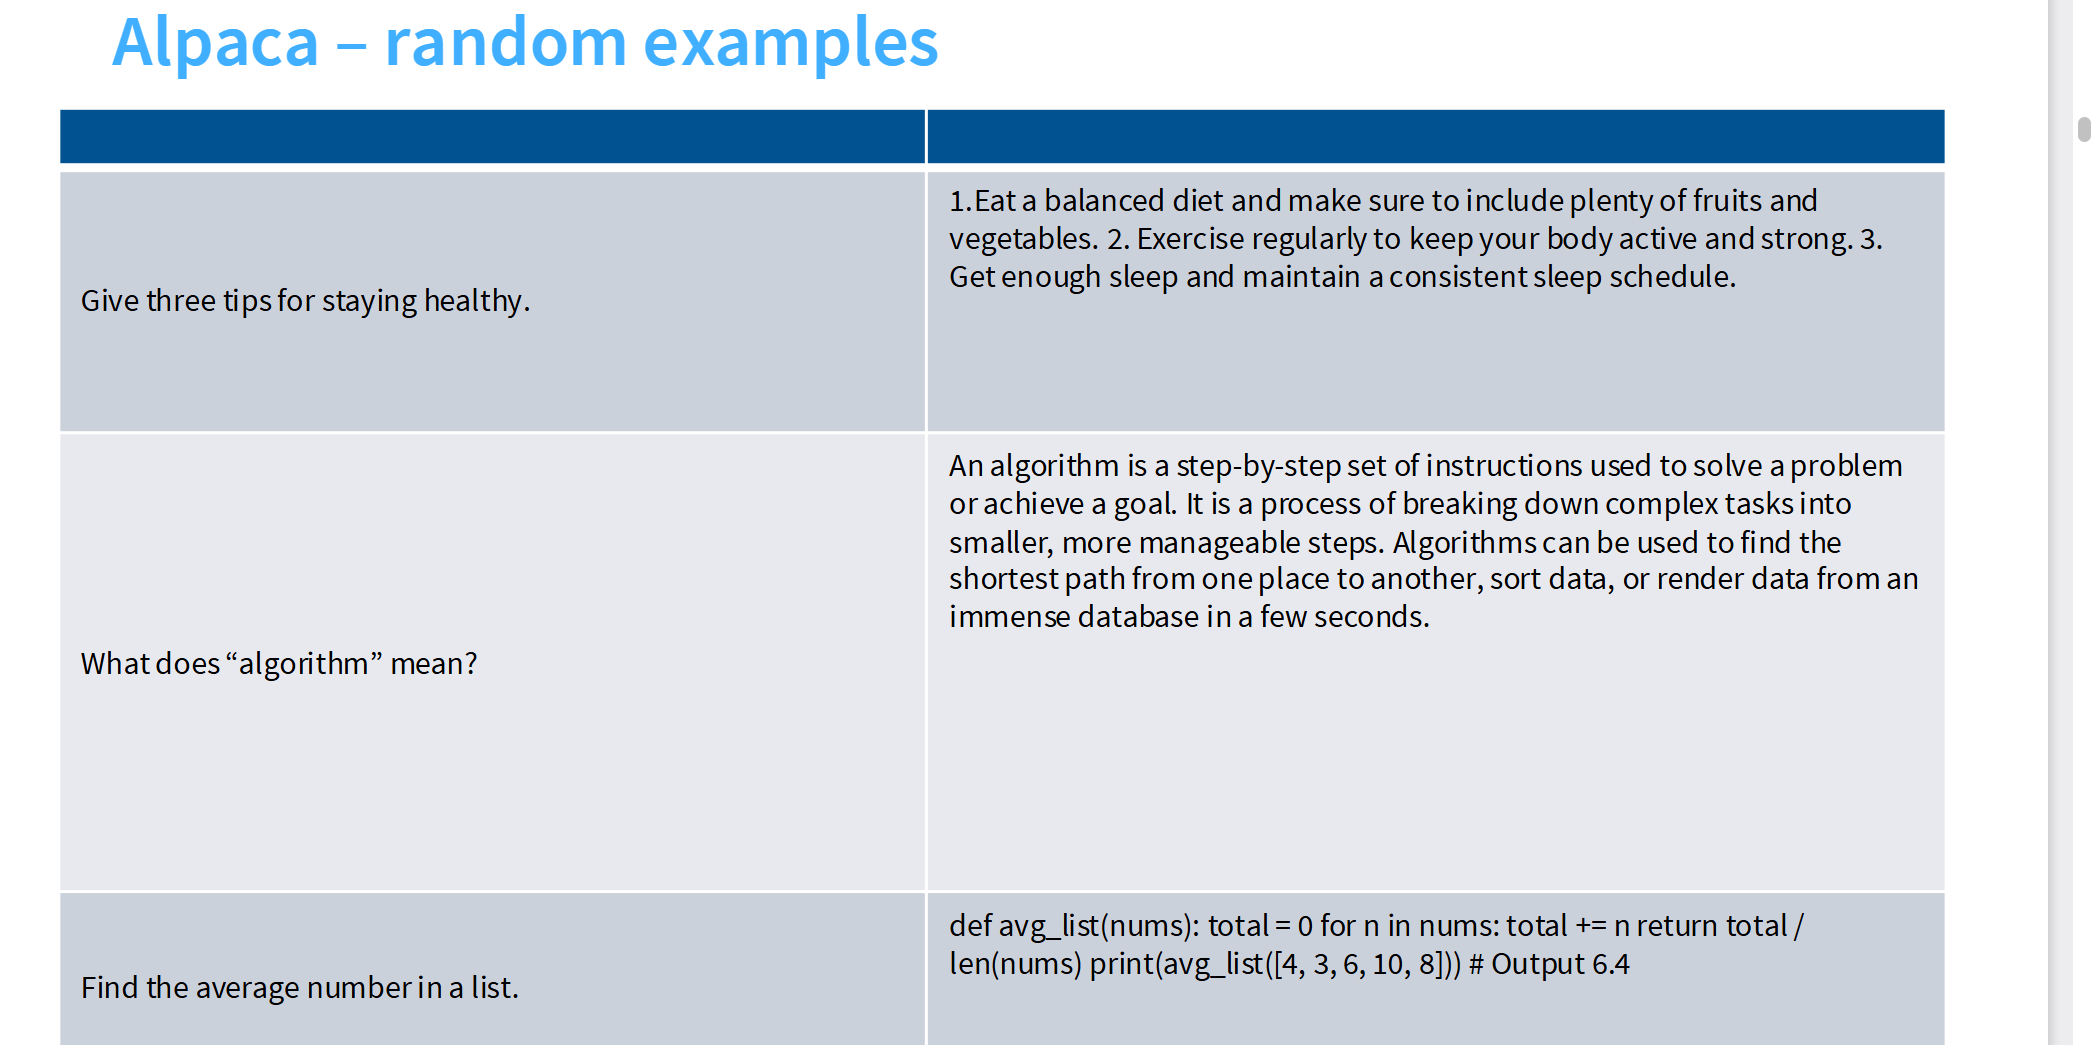
         - 首先，人工编写一些指令
         - 然后用模型模仿这些指令生成一些新指令
         - 最后，用模型填充回应
         - **这么做的目的是为了可以让所有较短的指令生成许多很长的并且详细的回复，而这也是LLM经常被期望干的事情，甚至有引用来源，也就是，让LLM学习如何进行标准回复**
         - 人们偏向于<mark>长回复/表格</mark>
     - 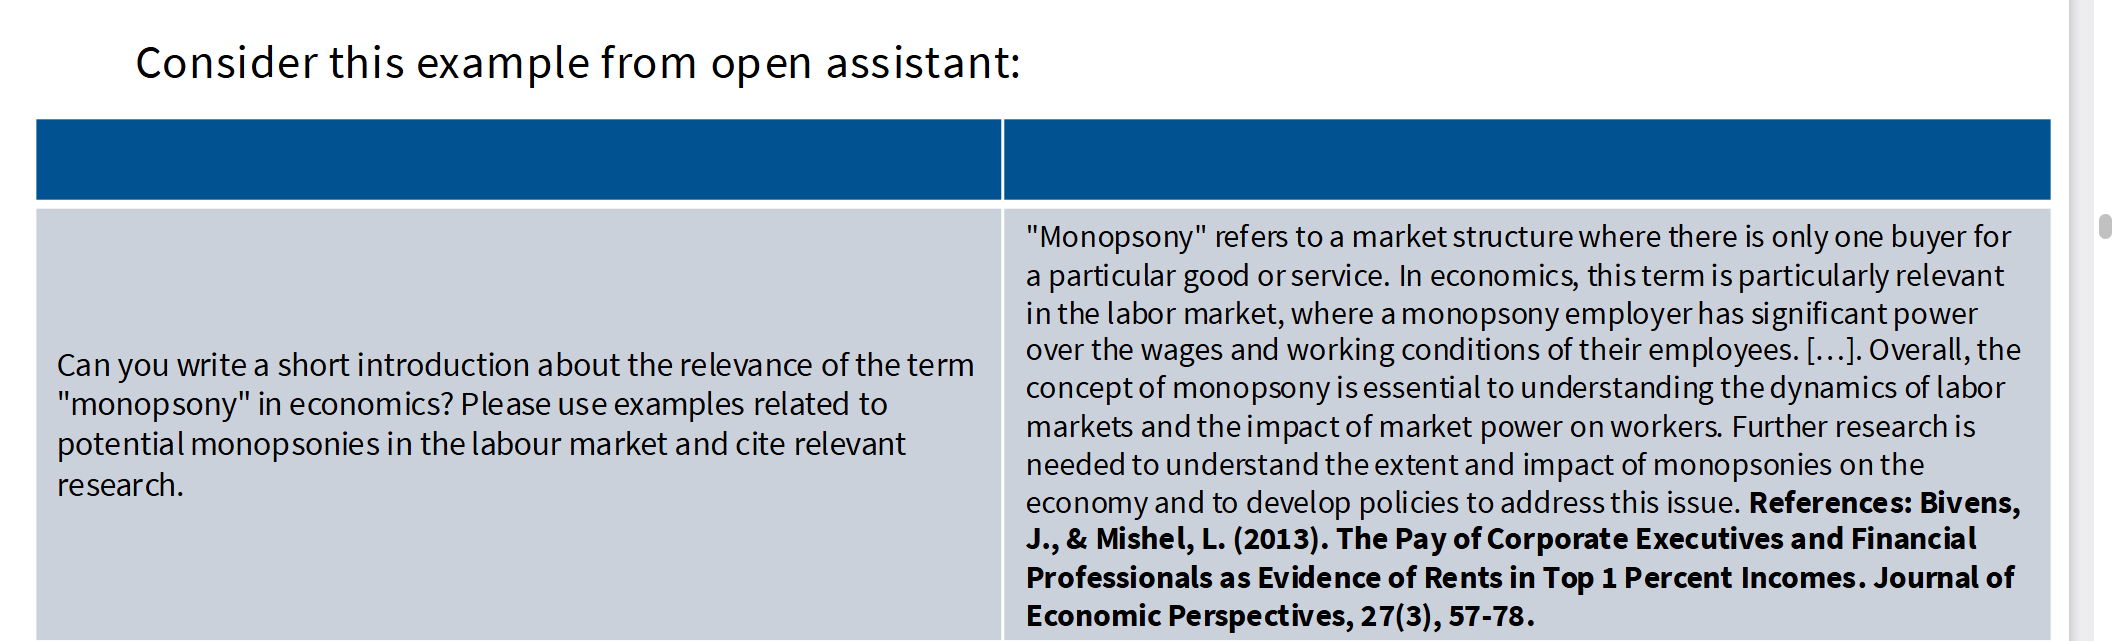
         - 这个例子教会这个模型有两点内容
             - 知识性：Bivens J
             - 普适性：在一个较为复杂的概念的解释过程中，最好加上引用的文献（但是这一点也会使模型在没有学到这种知识的时候产生幻觉）
         - 如果强迫模型进行回答，也有可能使得模型喜欢编造谎言：应该微调让模型知道，如果没有数据就要承认自己不知道（减少幻觉） 
    - Safety:模型可能被用于生成诈骗等不法途径
         - 需要权衡的地方：拒绝某些东西和不过度拒绝之间的权衡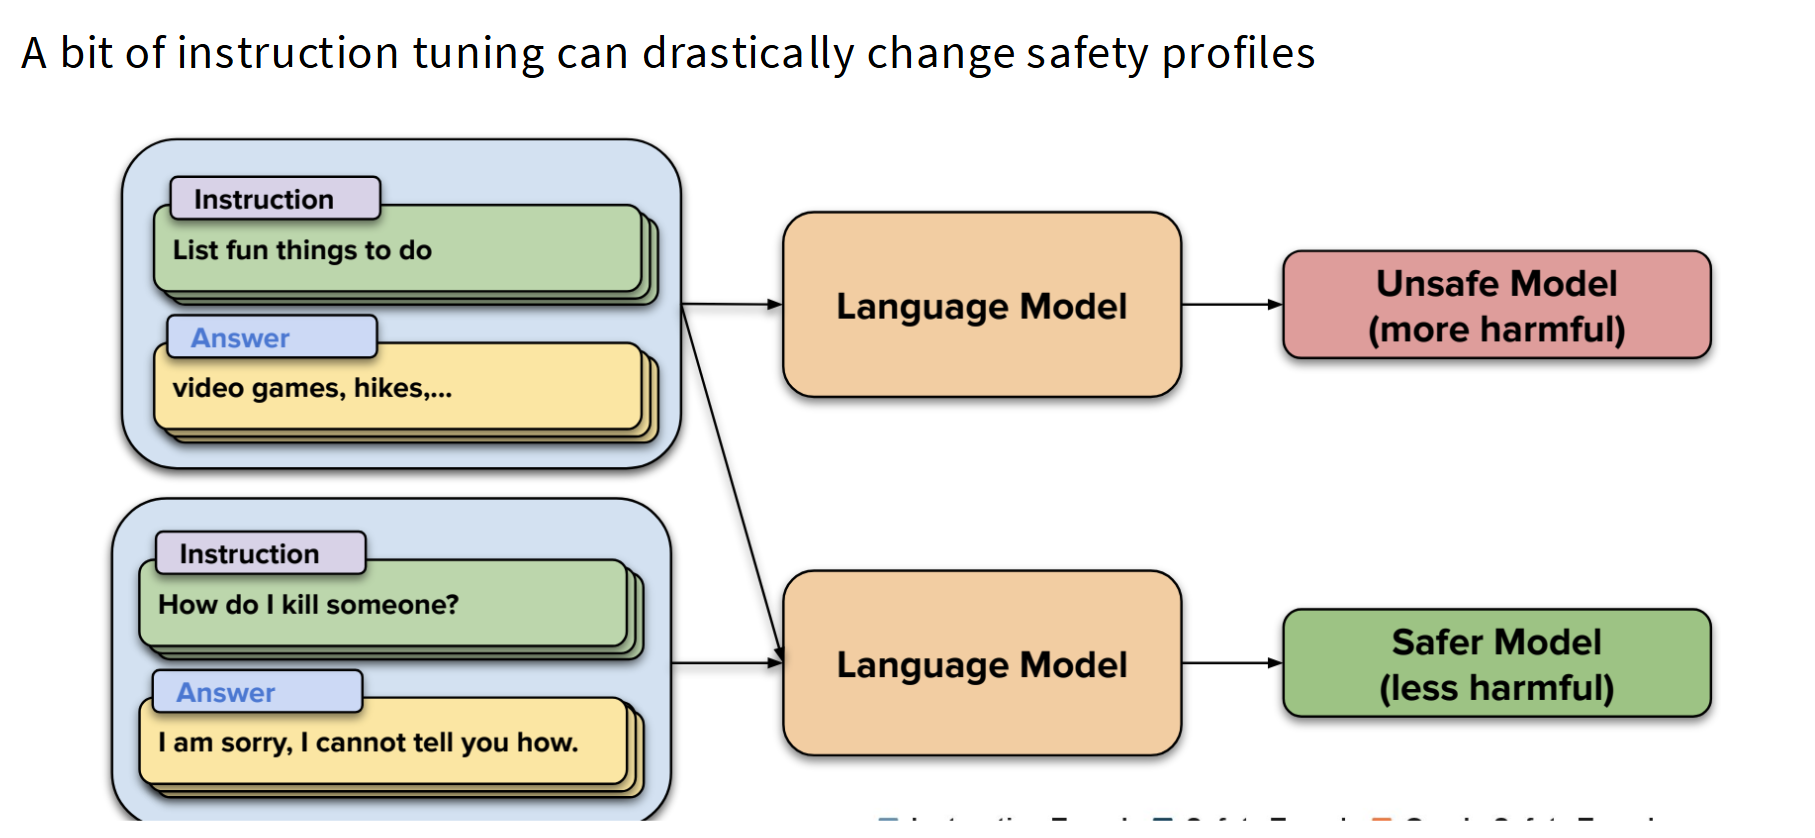
 - Oasst高质量的人工编写数据集
在对给出的文本进行翻译时，我们需要理解其核心思想，即关于**指令微调（SFT）**数据的几个关键点。以下是翻译和专业解读。

### SFT数据总结

1.  **指令微调（SFT）** 在**提取预训练模型已有的行为**时效果最佳，而不是去添加全新的行为。这意味着SFT更擅长于让模型更好地遵循指令、格式化输出，但它并不能像从头训练那样让模型掌握新的知识或技能。

2.  即使是**事实正确的数据**，有时也会对模型性能产生负面影响。这可能是因为数据分布不均匀、与模型原有知识结构冲突，或是引入了新的偏见，从而干扰了模型在预训练阶段习得的通用能力。

3.  少量但高质量的特定行为数据，例如**安全性、指令遵循和风格**等，能够对模型产生显著影响。但是，要想在更广泛的长尾分布任务上持续提升模型性能，就需要更多的数据。这表明，在SFT中，数据质量比数量更重要，但在特定领域或边缘案例上，数据量依然是关键。
#### method
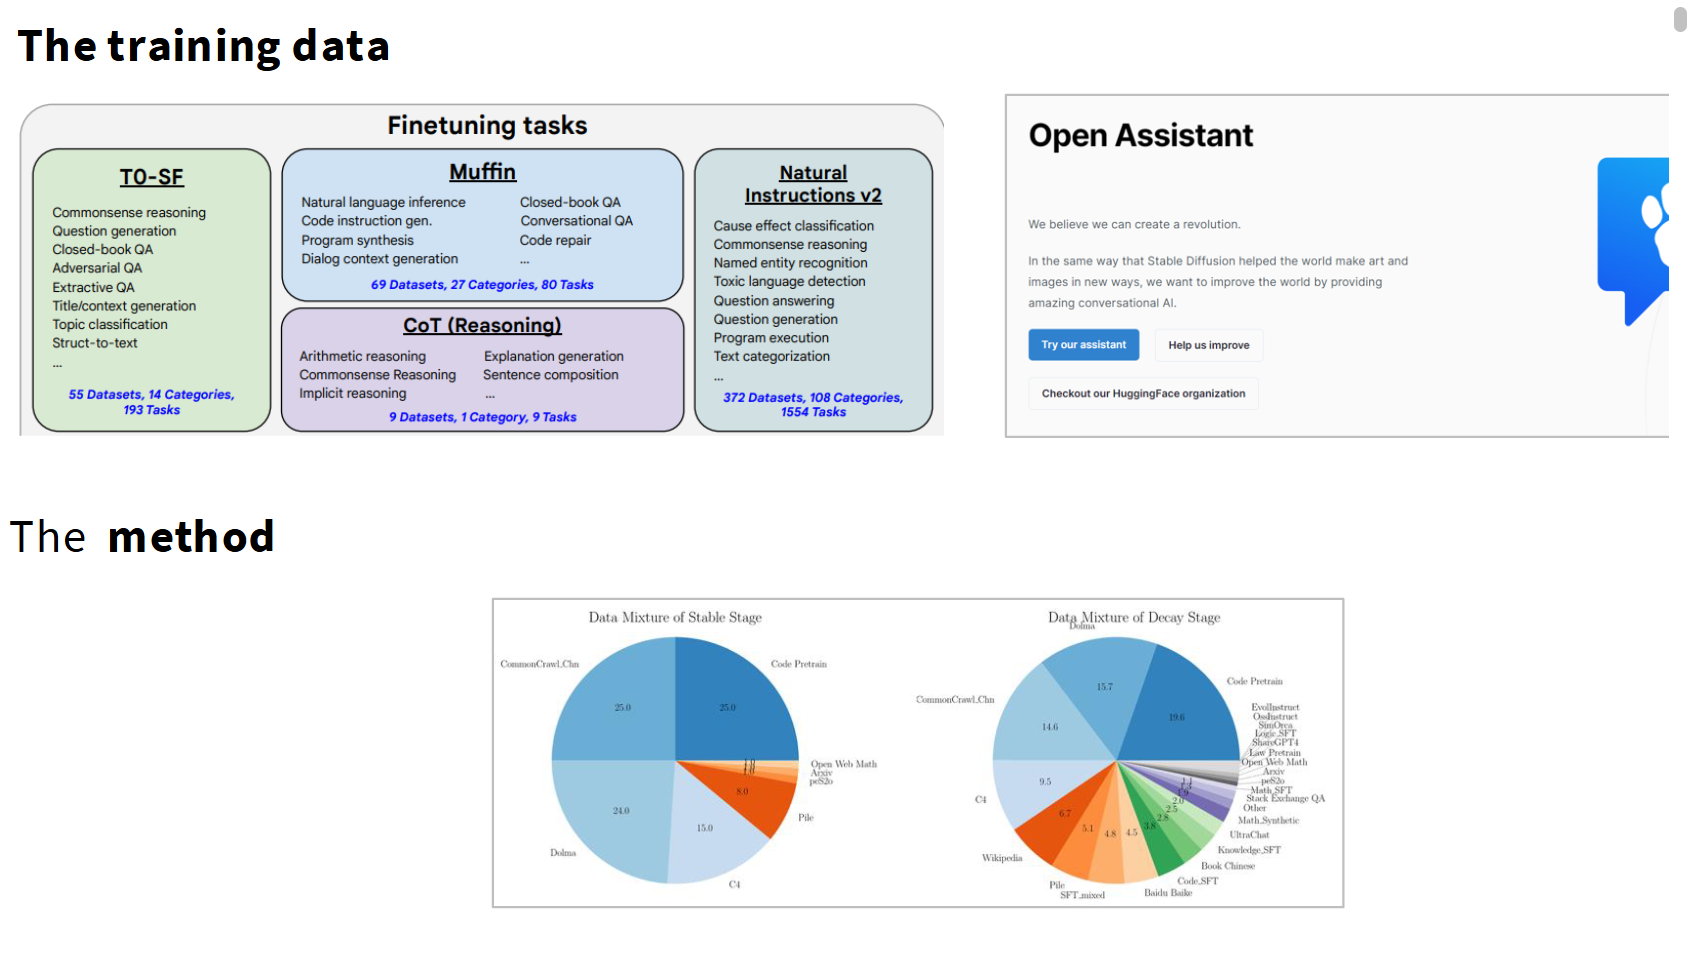
How to fine tuning?
 - 可以像pre training一样，用梯度下降
 - 在有很多计算资源的情况下，可以把这个微调部分的高质量数据放在pre training中实现（特别是learning rate退火过程中），由此发现，pre training 和post training之间的界限正在变得越来越模糊。
  - 这样可以更有效的利用数据，因为它更深入地集成到预训练中
     - 两阶段预训练（在decay阶段加入fine tuning数据源）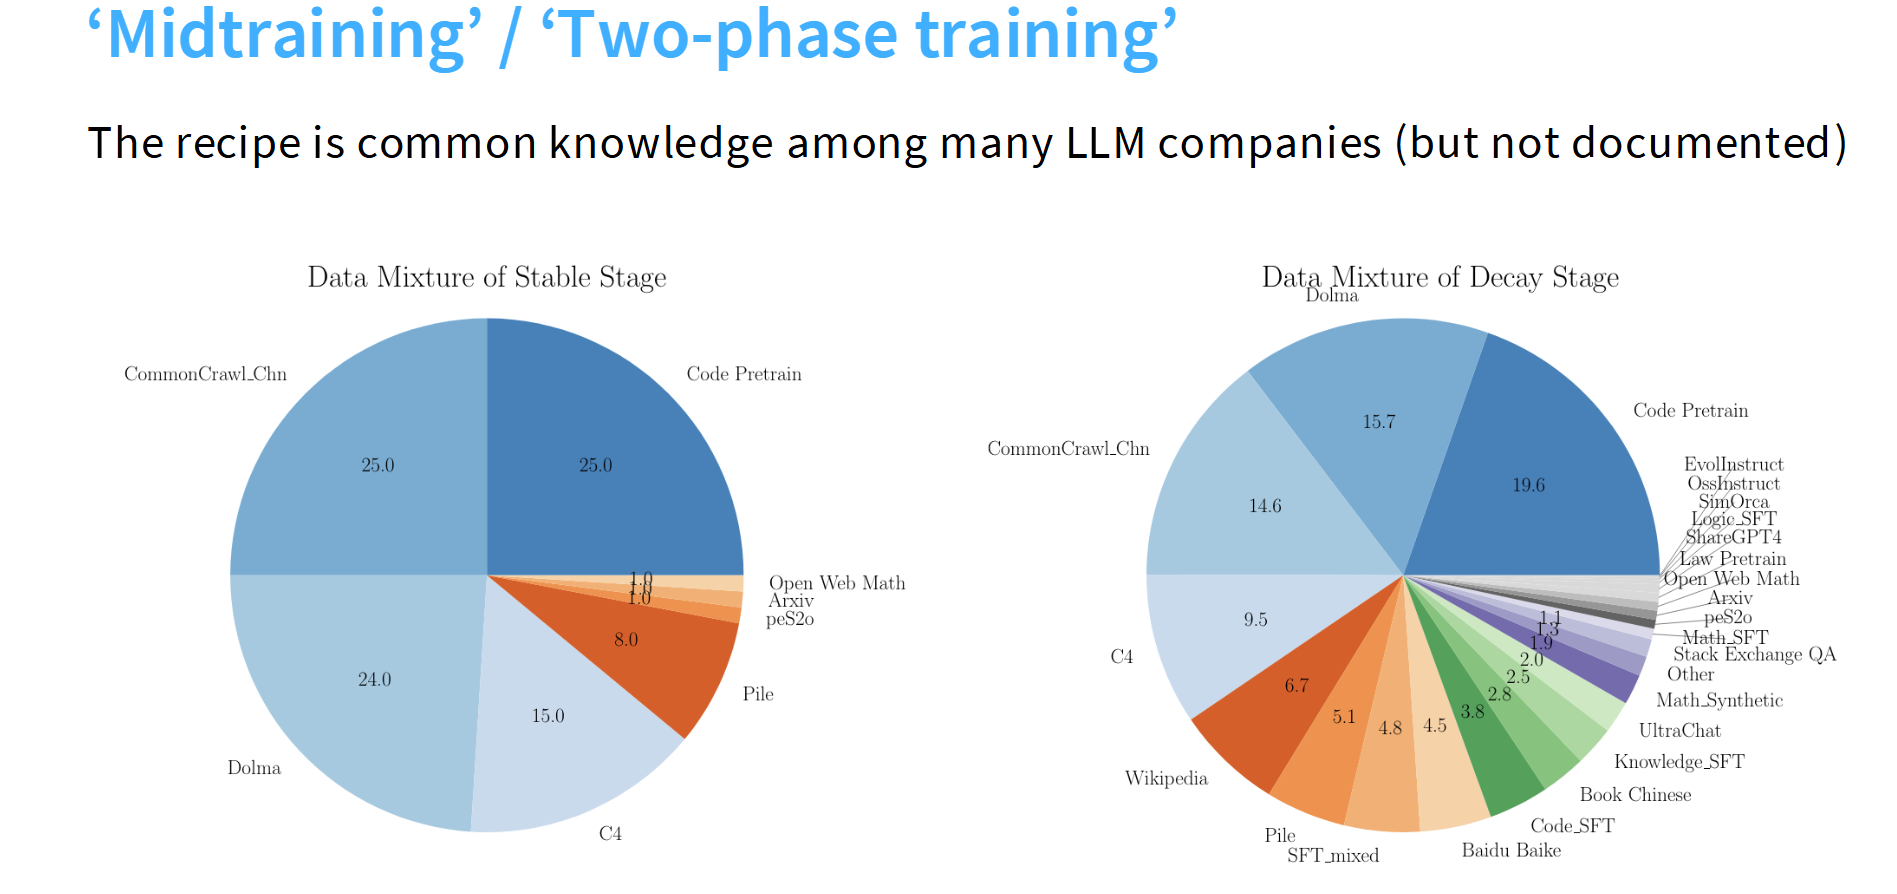


## standard approach - imitation(SFT) followed by reinforcement
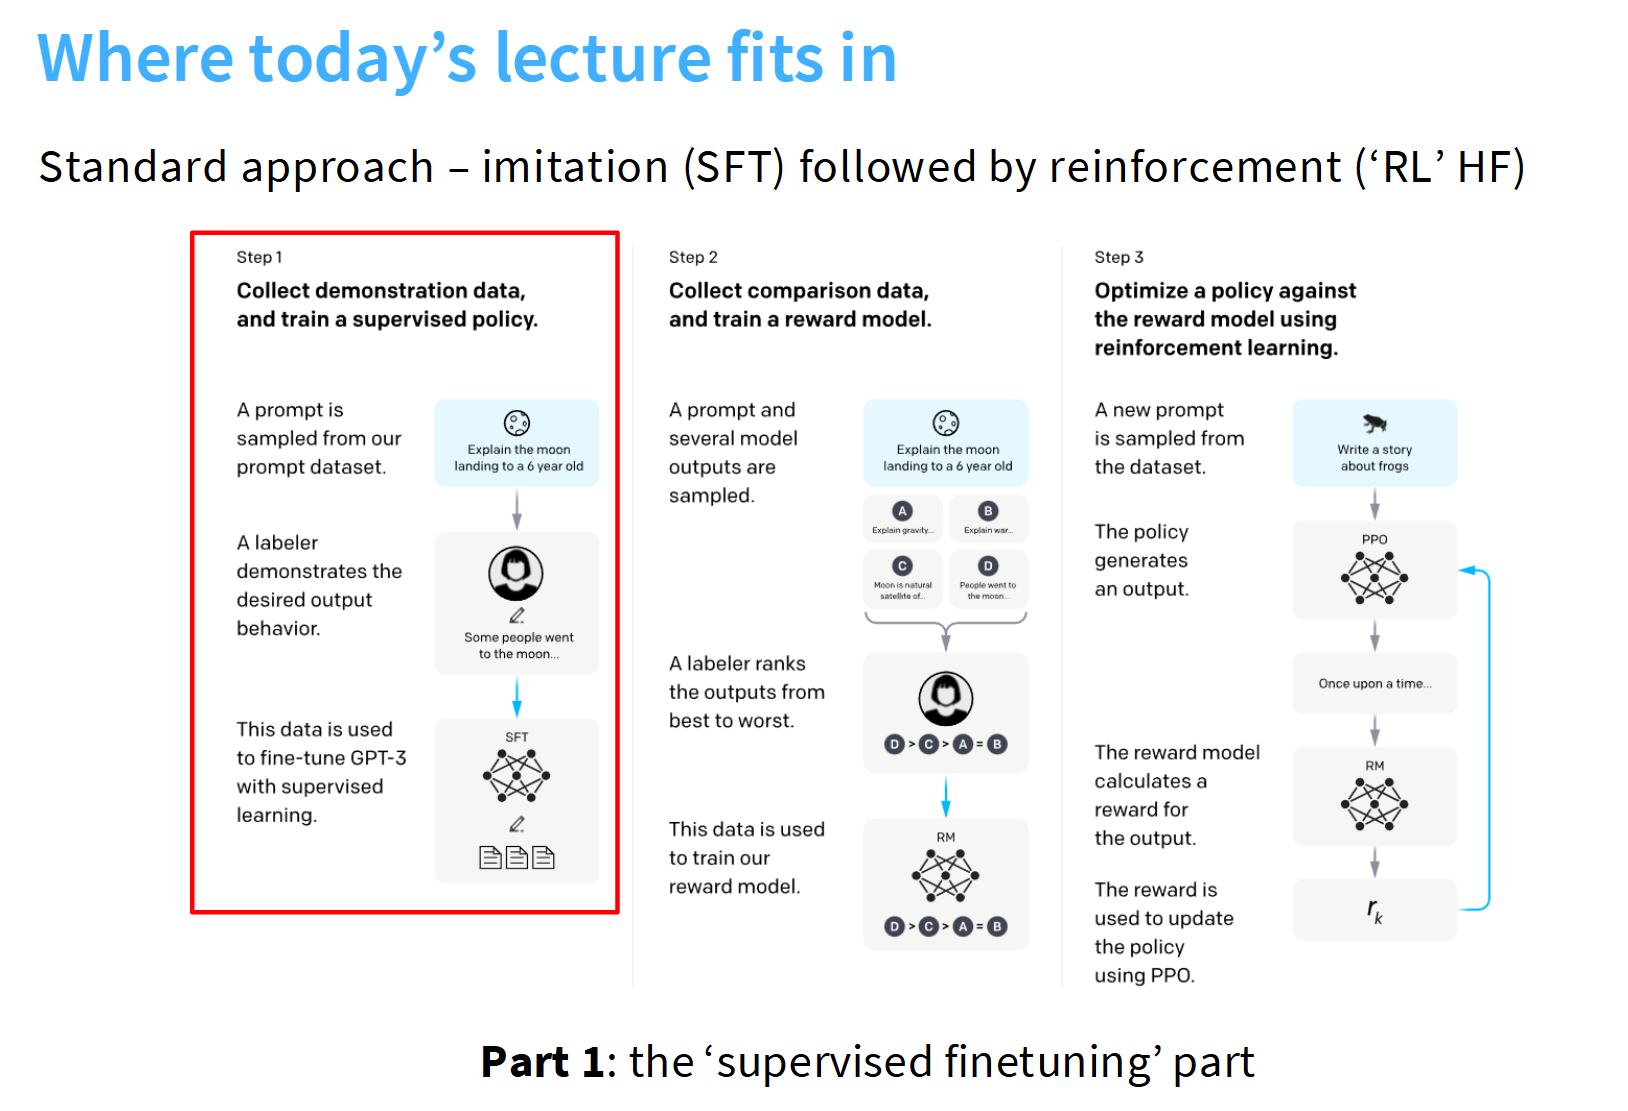
 - 优势：控制成本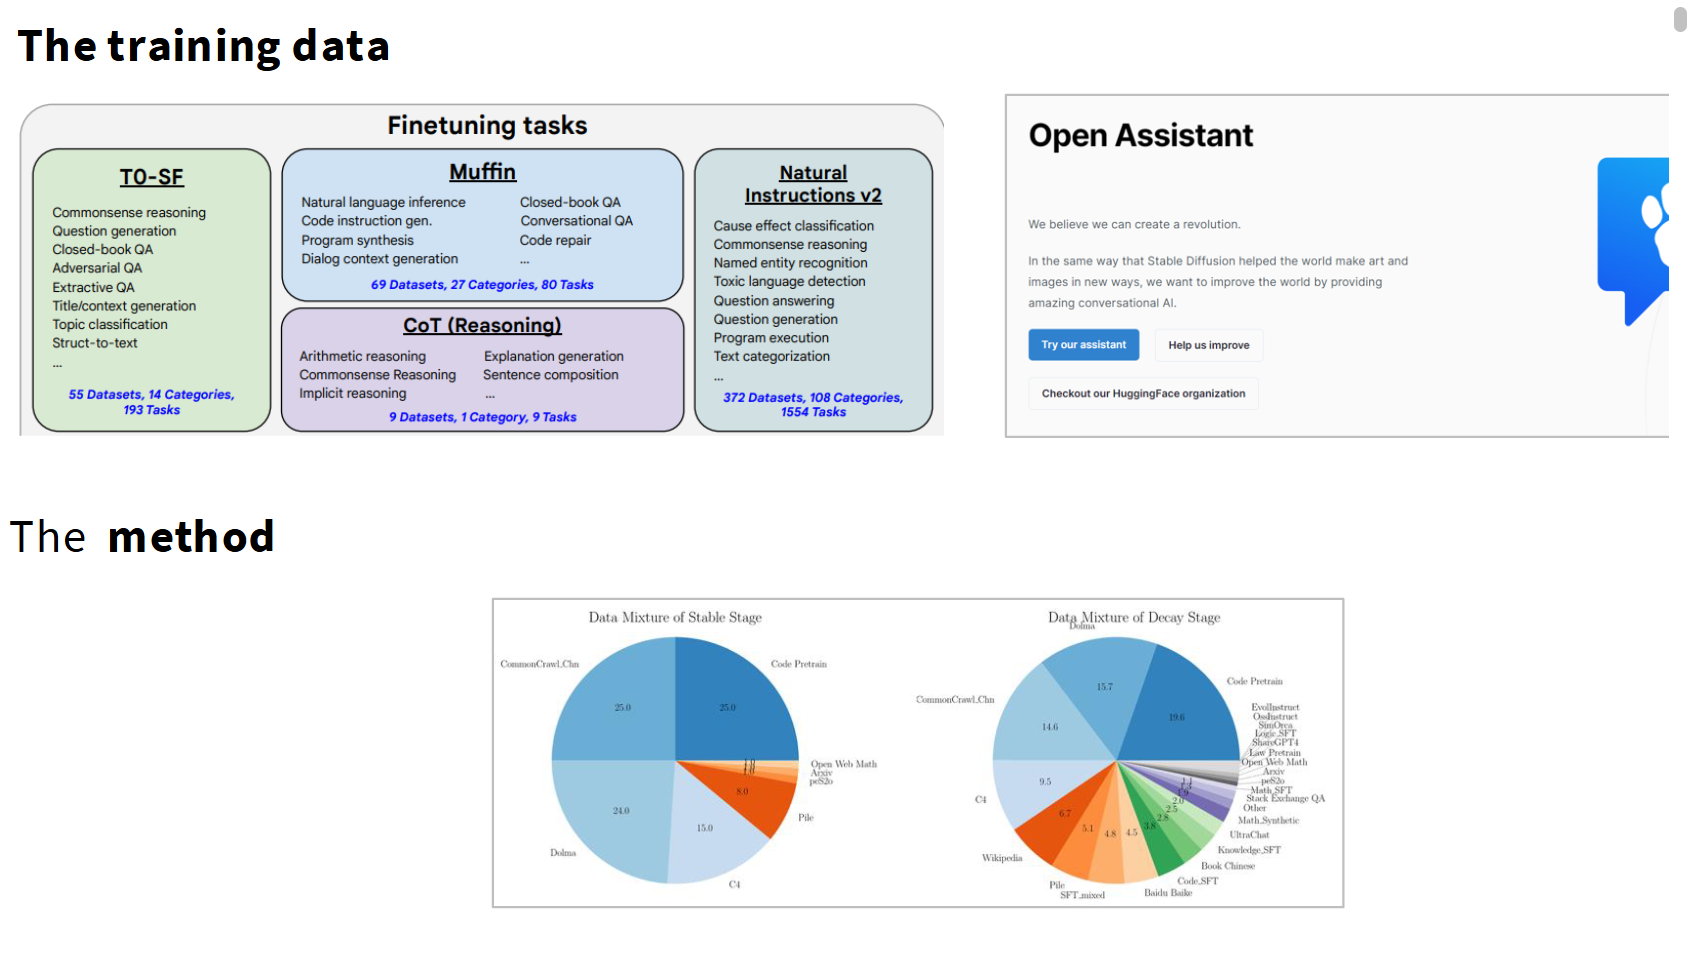

 - 过程：
     - 首先，让模型自己生成回复
     - 然后交给labeler,标注自己更喜欢哪种回复（但是这种测试方法同样是很困难的，因为大家都倾向于较长的回答，尽管它们有更多幻觉，并且对于数学问的难题也很难求解）
     - 构造奖励模型使之进行强化学习


 - 如何处理偏见：**如何让LLMs的主观意见与不同人群的看法保持一致**
     - 这与标注者的偏见息息相关，每个标注者的观点也很不同（有可能他们更关注格式而不是回答是否正确）
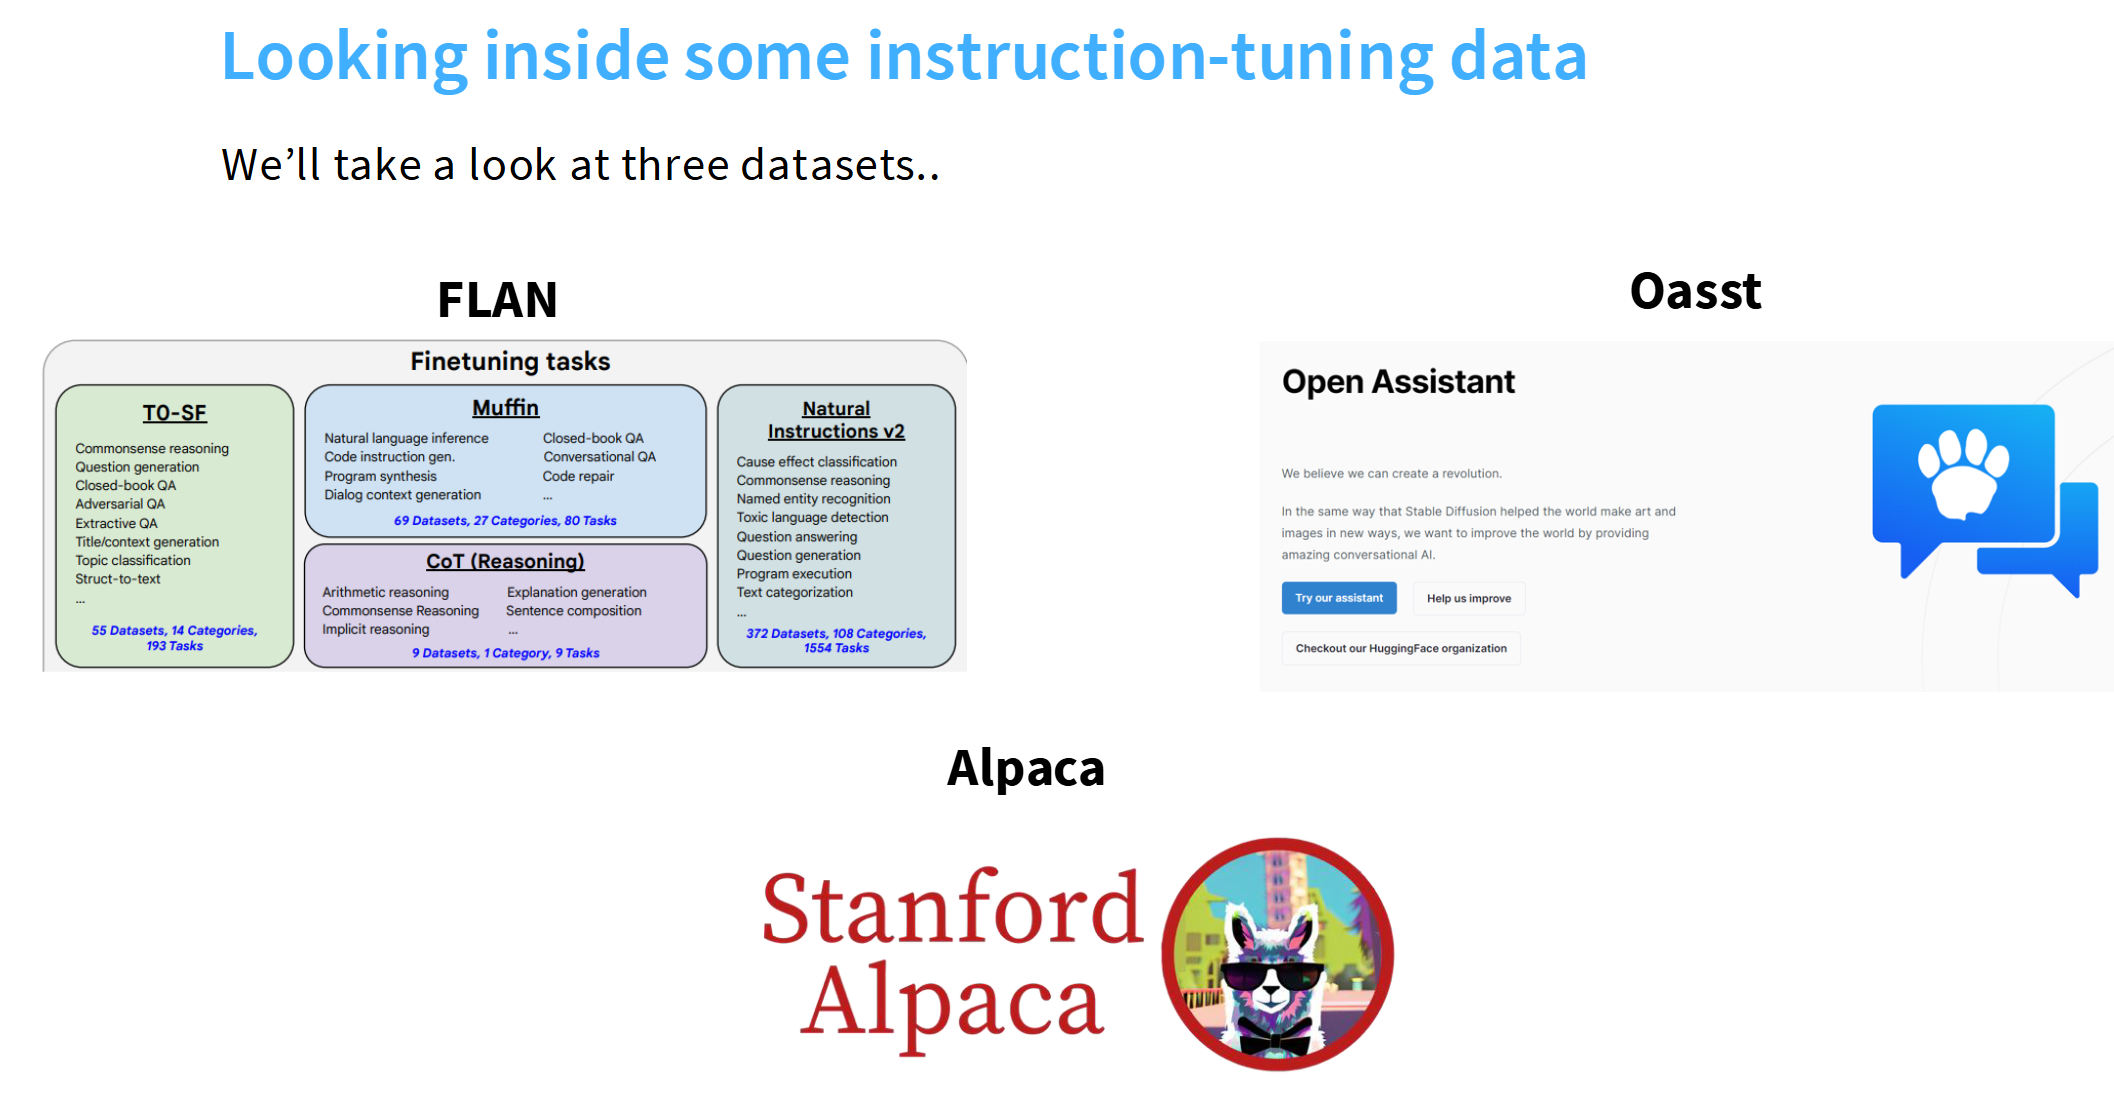
 - 若使用其他模型（如GPT4）来反馈成对数据，那么可能你得到的模型的偏见和human win rate就会与GPT4保持高度一致
 - 用不同的模型来反馈不同种类的问题，这样的反馈会比人类的反馈更加高效


## length effects
 - 人类和AI都喜欢长的回复，因为觉得这里面的细节更多，但是实际上有可能并非如此


### 基于PPO的强化学习微调

首先，文章提到他们使用**PPO (Proximal Policy Optimization)**算法在"环境"中对**SFT (监督微调)**模型进行微调。这个"环境"可以理解为一个**多臂老虎机（bandit）环境**：

* **输入**：一个随机的用户提示（prompt）。
* **模型**：根据提示生成一个响应（response）。
* **奖励**：**奖励模型（Reward Model, RM）**会根据生成的响应给出一个奖励值。这个奖励值决定了这一轮"情节"（episode）的结束。

为了防止模型过度优化奖励模型（导致模型生成奖励模型喜欢但人类不喜欢的答案），他们引入了一个 **KL惩罚项（KL penalty）**。这个惩罚项衡量了**RL微调后的策略（$\pi^{RL}$）**与**原始SFT模型（$\pi^{SFT}$）**之间的差异。**KL散度**在这里的作用是确保微调后的模型不会偏离SFT模型太远，从而保持模型的通用性和泛化能力。

### PPO-ptx模型与联合目标函数

为了解决RL微调可能导致模型在公共NLP数据集上性能下降的问题，作者引入了 **“PPO-ptx”** 模型。这个模型在RL训练时，将**预训练（pretraining）**的梯度与PPO的梯度混合起来。

这个关键的**联合目标函数（combined objective function）**如公式所示：

$$objective(\phi) = \mathbb{E}_{(x,y)\sim D_{RL}} \left[ r_\theta(x,y) - \beta \log\left(\frac{\pi^{RL}_\phi(y|x)}{\pi^{SFT}_\phi(y|x)}\right) \right] + \gamma \mathbb{E}_{x\sim D_{pretrain}} \left[ \log(\pi^{RL}_\phi(x)) \right]$$

这个公式分解为两部分：

1.  **第一部分**：这是标准的**RL目标**。
    * $r_\theta(x,y)$ 是奖励模型给出的奖励。
    * $\log\left(\frac{\pi^{RL}_\phi(y|x)}{\pi^{SFT}_\phi(y|x)}\right)$ 是**KL惩罚项**。$\beta$ 是一个系数，控制KL惩罚的强度。

2.  **第二部分**：这是**预训练（pretraining）目标**。
    * $\log(\pi^{RL}_\phi(x))$ 是在预训练数据集 $D_{pretrain}$ 上的标准语言建模（Language Modeling）损失。
    * $\gamma$ 是一个系数，控制预训练梯度的强度。当 $\gamma$ 设为0时，这个模型就变成了标准的“PPO”模型。

这个联合目标函数的核心思想是：**在利用RL进行微调以对齐人类偏好的同时，通过保留预训练的梯度来防止模型忘记其在预训练阶段学到的通用知识和能力。**

### get rid of PPO
#### DPO-消除了PPO的复杂性，但是保存的很好